<a href="https://colab.research.google.com/github/SivaPanadi27/Telecom-Customer-Retention-ML-System/blob/main/Random%20Forest.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. Problem Statement

This project aims to build a Machine Learning model to predict customer churn in a telecom company.

Telecom companies provide services such as mobile calls, internet data, SMS, broadband, and TV bundles. Customers subscribe to these services through monthly or yearly plans.

When a customer stops using the service or switches to another provider, it results in revenue loss. This phenomenon is known as customer churn.

The goal of this project is to predict whether a customer will churn in advance, allowing the company to take proactive measures such as offering discounts, improving services, or providing better plans to retain customers.


## 1.1 Machine Learning Problem

- Type of Problem: Binary Classification
- Target Variable: Churn (Yes/No)
- Objective: Predict whether a customer will churn or not based on given features


## 1.2 Evaluation Metric

In churn prediction, the dataset is often imbalanced, meaning the number of non-churn customers is higher than churn customers.

- Accuracy is not a reliable metric in this case.
- F1 Score is preferred as it balances precision and recall.
- Recall is also important because missing a churn customer can lead to business loss.

Therefore, the primary evaluation metric for this project will be F1 Score.

In [1]:
#Importing Libraries


#1.For Data Handling
import numpy as np
import pandas as pd
import numpy as np

#2.For Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# For Data-Preprocessing
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# For Splitting the data
from sklearn.model_selection import train_test_split, cross_val_score,StratifiedKFold

# For Models
from sklearn.linear_model import LogisticRegression,Perceptron
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

#Evalution Metrics
from sklearn.metrics import classification_report,precision_score,recall_score, f1_score, accuracy_score, confusion_matrix,roc_auc_score,roc_curve,precision_recall_curve



**Step1: Data Collection**

To train our machine learning models, we collected the dataset from Google Dataset Search.


The dataset used is the Telecom Churn Dataset, which contains information about customers and whether they have churned (left the service) or continued using the service.


The dataset is available in CSV (Comma Separated Values) format, which stores data in a tabular structure with rows and columns.

The dataset contains 7043 customer records and 52 features.

In [2]:
#Step-2: Loading the dataset
df = pd.read_csv("Telecom_dataset.csv")


In [3]:
#Step-3: Data Inspection


# 1)head(): It returns us the first five rows of the dataset. If we need any specific number of rows then we can mention it as head(number_of_required)
df.head()

# 2)tail(): It returns us the last five rows of the dataset. if we need any specific number of rows then we can mention it as tail(number_of_required)
df.tail()

# 3)Info():It tells us the what columns are presennt in the dataset their datatype and non-null count
df.info()

# 4)Describe(): It gives us the stastical outcomes of the  numerical columns in dataset such as mean, std etc...
df.describe()

# 5)Describe(): It gives us the stastical outcomes of the categorical columns in dataset
df.describe(include='object')

# 6) Columns: It returns the columns present in the dataset
df.columns

#7)Shape: It returns the matrix of rows and columns present in the dataset
df.shape

# 8)value_counts:It is used on target variable to get to know whether the dataset is balanced or imblanced
df["Churn"].value_counts()

# 9) Missing values
df.isnull().sum()

# 10) Duplicate rows
df.duplicated().sum()

# 11) Unique values in each column
df.nunique()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 52 columns):
 #   Column                             Non-Null Count  Dtype  
---  ------                             --------------  -----  
 0   Age                                7043 non-null   int64  
 1   Avg Monthly GB Download            7043 non-null   int64  
 2   Avg Monthly Long Distance Charges  7043 non-null   float64
 3   Churn Category                     1869 non-null   object 
 4   Churn Reason                       1869 non-null   object 
 5   Churn Score                        7043 non-null   int64  
 6   City                               7043 non-null   object 
 7   CLTV                               7043 non-null   int64  
 8   Contract                           7043 non-null   object 
 9   Country                            7043 non-null   object 
 10  Customer ID                        7043 non-null   object 
 11  Customer Status                    7043 non-null   objec

,0
Age,62
Avg Monthly GB Download,50
Avg Monthly Long Distance Charges,3584
Churn Category,5
Churn Reason,20
Churn Score,81
City,1106
CLTV,3438
Contract,3
Country,1


## 3. Initial Data Inspection - Observations

### 1. Dataset Shape
- The dataset contains **7043 rows and 52 columns**.
- This indicates a relatively high number of features compared to observations.

---

### 2. Data Types
- The dataset consists of both **numerical and categorical features**.
- Categorical features are stored as `object` type.

---

### 3. Missing Values
Missing values are present in the following columns:
- Churn Category
- Churn Reason
- Internet Type
- Offers

All other columns do not contain missing values.

**Insight:**
- Missing values in "Churn Category" and "Churn Reason" are likely related to non-churn customers.
- These columns may not be useful for prediction and could lead to data leakage.

---

### 4. Target Variable Distribution
- The dataset is **imbalanced**.
- The ratio of non-churn to churn customers is approximately **2.7 : 1**.

**Insight:**
- Accuracy is not a reliable metric.
- Evaluation should focus on **F1-score and Recall**.

---

### 5. Duplicate Records
- No duplicate rows were found in the dataset.

---

### 6. Statistical Summary
- Numerical features show standard statistics such as mean, median, standard deviation, etc.
- Categorical features show frequency, most common value, and count.

**Insight:**
- Further analysis will be required to understand feature importance and distributions.

In [4]:
# Step-4. Data Cleaning


# 4.1 Removing Data Leakage Columns


df.drop(["Churn Reason", "Churn Category", "Churn Score", "Customer Status","Satisfaction Score"], axis=1, inplace=True)

"""
These columns contain post-outcome information about churn.
Including them would lead to data leakage, as the model would learn from future information.
Hence, they are removed.
"""

# 4.2 Handling Duplicate Records

duplicates = df.duplicated().sum()
print("Duplicate Rows:", duplicates)

"""
No duplicate rows found no action required.
"""

# 4.3 Handling Missing Values


print("Missing Values Before Handling:\n", df.isnull().sum())

"""
Missing values observed in:
- Internet Type
- Offer
"""

# Handling categorical missing values
df["Offer"].fillna("No Offer", inplace=True)
df["Internet Type"].fillna("Unknown", inplace=True)

print("Missing Values After Handling:\n", df.isnull().sum())

"""
'Offer' had  50% missing values mode imputation would introduce bias
  replaced with "No Offer"
'Internet Type' replaced with "Unknown"
"""

# 4.4 Fixing Data Types

print(df.dtypes)

"""
All columns are in appropriate data types → no conversion required.
"""


# 4.5 Removing Irrelevant Features


# Columns with single unique value
df.drop(["Country", "State", "Quarter"], axis=1, inplace=True)

# ID and high-cardinality non-informative columns
df.drop(["Customer ID", "Zip Code"], axis=1, inplace=True)

# Geographical columns
df.drop(["Latitude", "Longitude", "Lat Long", "City"], axis=1, inplace=True)

print("Remaining Columns:\n", df.columns)
print("Shape after cleaning:", df.shape)

"""
- Single-value columns → no predictive power
- Customer ID → unique identifier
- Zip Code → high cardinality, low relevance
- Geographical features dropped for simplicity
"""

# 4.6 Feature Consistency Check


# Categorical columns
print("\nCategorical Feature Values:\n")
for col in df.select_dtypes(include=['object']):
    print(col, ":", df[col].unique())

# Binary columns check
print("\nBinary Feature Values:\n")

binary_cols = [
    "Gender", "Dependents", "Married", "Multiple Lines", "Online Security",
    "Paperless Billing", "Online Backup", "Device Protection Plan",
    "Premium Tech Support", "Streaming TV", "Streaming Movies",
    "Streaming Music", "Unlimited Data", "Partner", "Phone Service"
]

for col in binary_cols:
    print(col, ":", df[col].unique())

"""
All categorical and binary columns contain consistent and expected values.
No anomalies detected.
"""

Duplicate Rows: 0
Missing Values Before Handling:
 Age                                     0
Avg Monthly GB Download                 0
Avg Monthly Long Distance Charges       0
City                                    0
CLTV                                    0
Contract                                0
Country                                 0
Customer ID                             0
Dependents                              0
Device Protection Plan                  0
Gender                                  0
Internet Service                        0
Internet Type                        1526
Lat Long                                0
Latitude                                0
Longitude                               0
Married                                 0
Monthly Charge                          0
Multiple Lines                          0
Number of Dependents                    0
Number of Referrals                     0
Offer                                3877
Online Backup            

/tmp/ipykernel_3294/3927497882.py:36: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Offer"].fillna("No Offer", inplace=True)
/tmp/ipykernel_3294/3927497882.py:37: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

'\nAll categorical and binary columns contain consistent and expected values.\nNo anomalies detected.\n'

EDA (Exploratory Data Analysis) is performed to understand patterns, relationships, and distributions in the dataset before building machine learning models.

EDA helps in:
- Understanding feature distributions
- Identifying relationships between features and target
- Detecting imbalances and anomalies

Types of EDA:
1. Target Analysis
2. Univariate Analysis
3. Bivariate Analysis

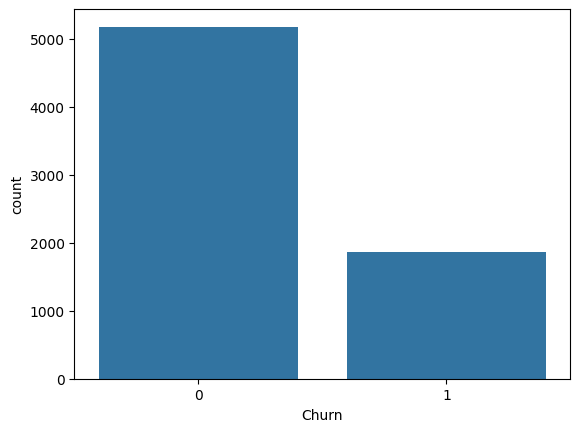

In [5]:
#Step-5:EDA
#5.1 Target Analysis: It means to understand the distribution of the target.

# Target Distribution
df["Churn"].value_counts()

# Percentage distribution
df["Churn"].value_counts(normalize=True) * 100

'''Insights:

- The dataset is moderately imbalanced.
- The number of customers who did not churn is significantly higher than those who churned.
- The ratio is approximately 2.7:1.

Implications:

- Accuracy is not a reliable metric.
- A model predicting all customers as "No Churn" would still achieve ~73% accuracy.
- Therefore, better evaluation metrics such as:
  - F1 Score
  - Recall
  - Precision
  should be used.

Strategy:

- Use `class_weight="balanced"` in models like Logistic Regression.
- Consider advanced imbalance handling techniques if needed.'''
import seaborn as sns
import matplotlib.pyplot as plt
sns.countplot(x="Churn",data=df)
plt.show()


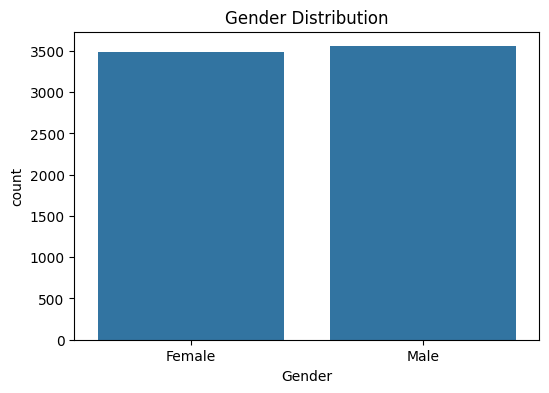

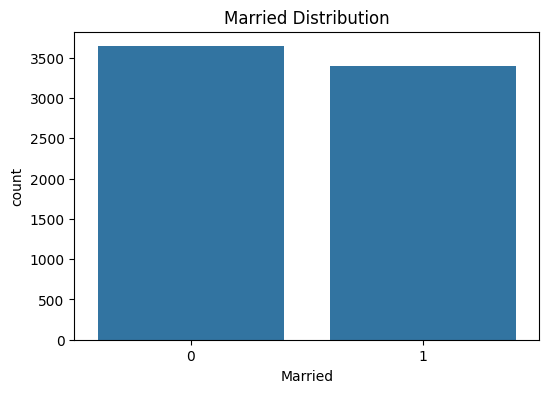

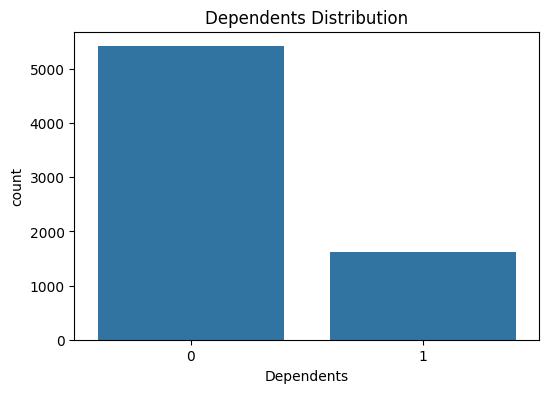

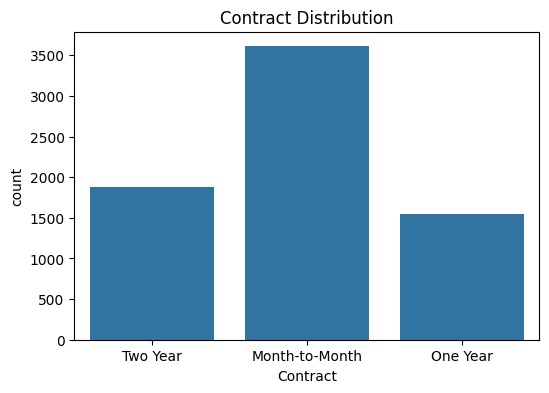

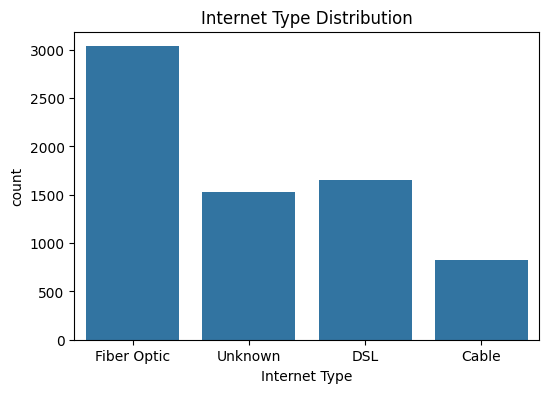

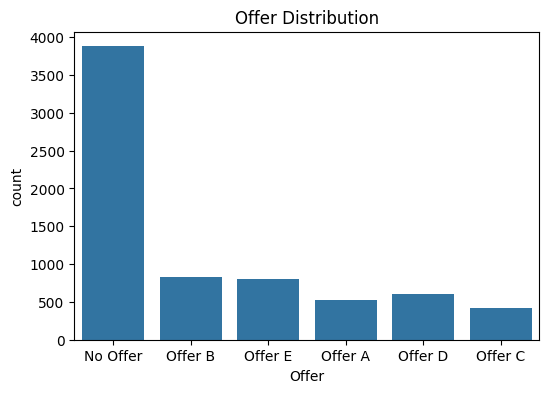

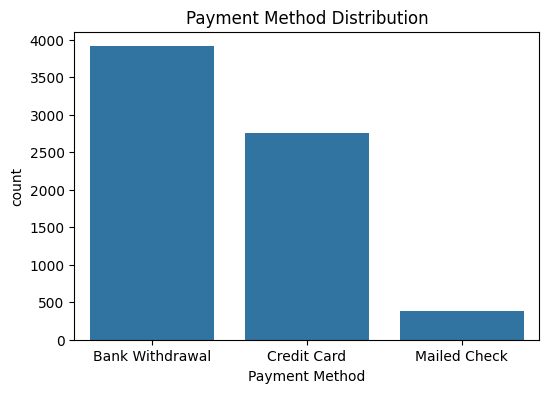

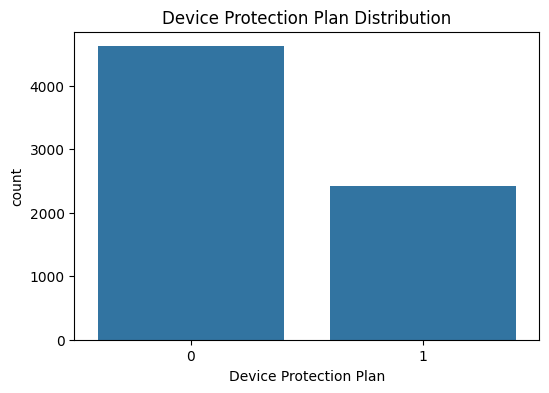

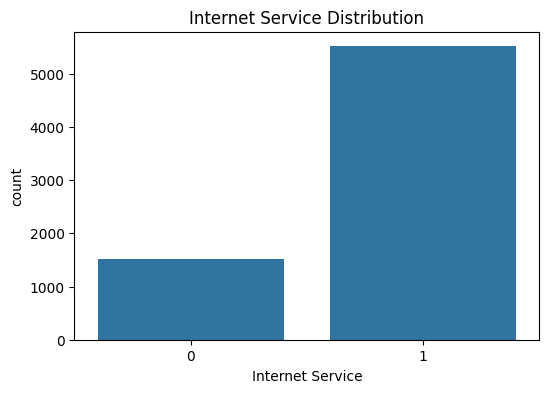

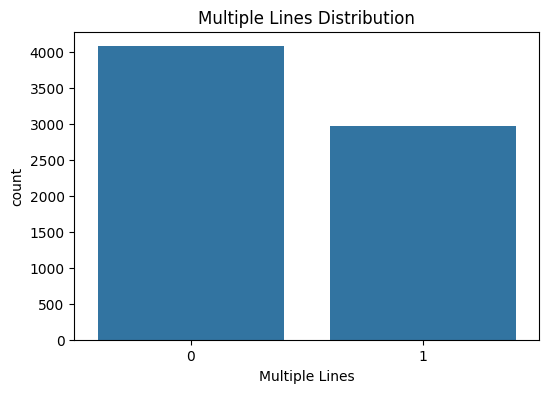

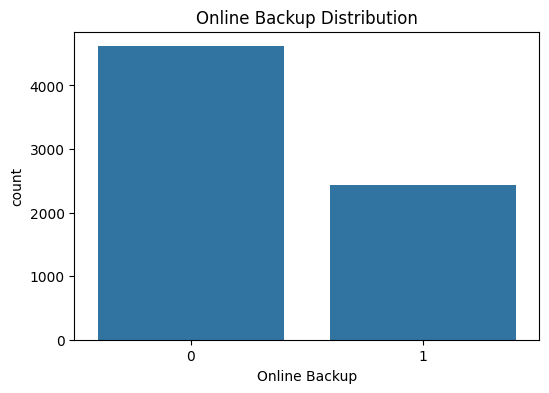

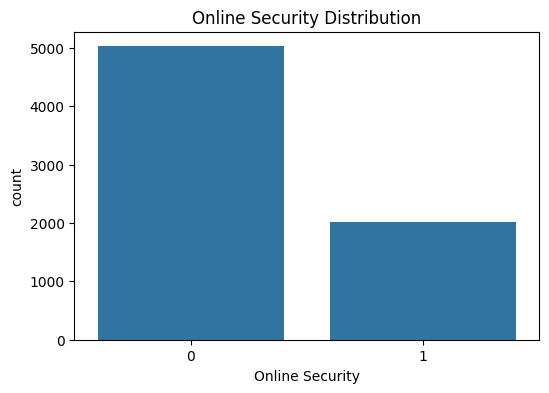

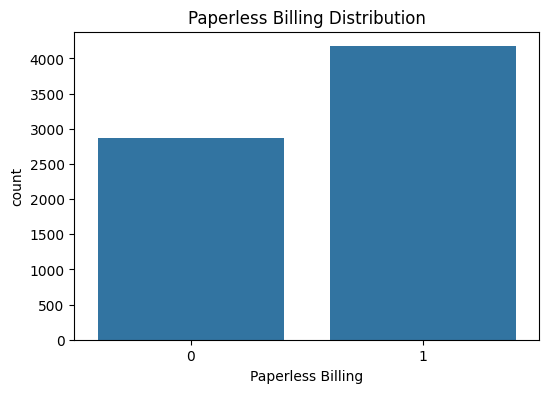

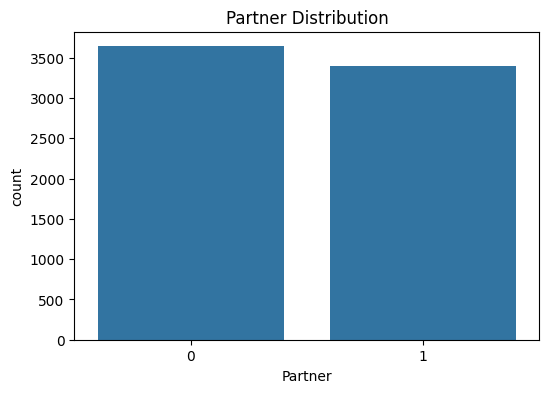

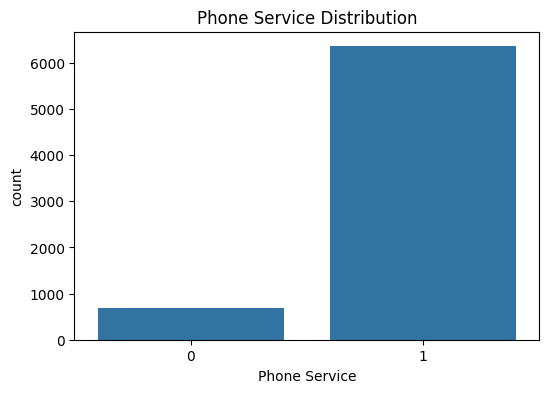

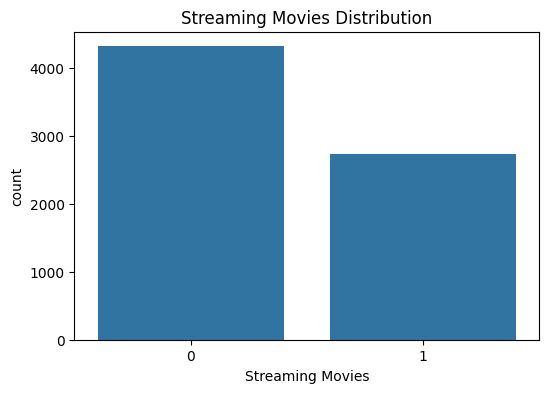

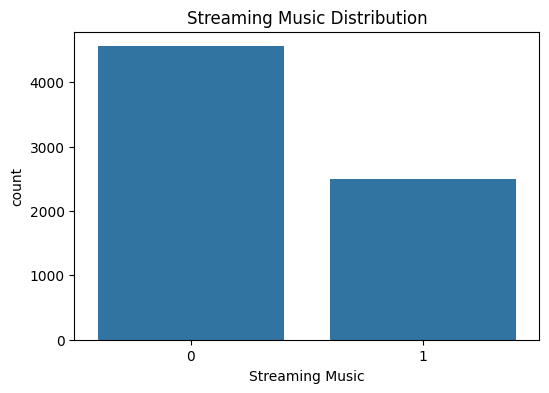

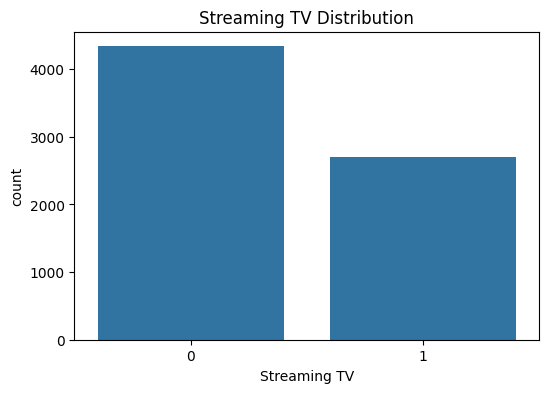

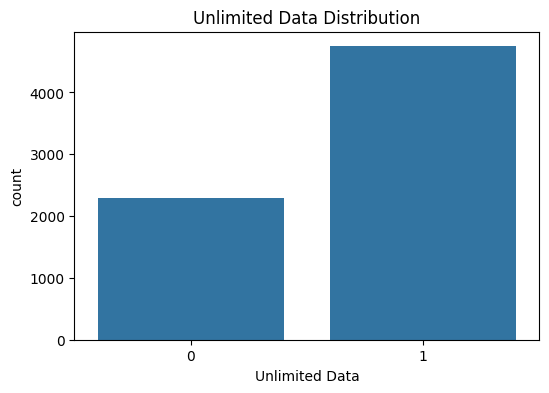

In [6]:
#6.2 Univariate Analysis
#Categorical Features
categorical_cols = [
    'Gender','Married','Dependents','Contract','Internet Type','Offer',
    'Payment Method','Device Protection Plan','Internet Service',
    'Multiple Lines','Online Backup','Online Security','Paperless Billing',
    'Partner','Phone Service','Streaming Movies','Streaming Music',
    'Streaming TV','Unlimited Data'
]

for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, data=df)
    plt.title(f"{col} Distribution")
    plt.show()

## 6.2.1 Univariate Analysis – Insights

### Demographics
- Gender is almost evenly distributed between male and female customers.
- Similarly, the number of married and unmarried customers is balanced.

This suggests that demographic factors alone may not strongly influence churn.

---

### Dependents
- Most customers do not have dependents.
- Even among those who do, the number of dependents is generally low.

This indicates that dependents are not a dominant characteristic in this dataset.

---

### Contract Type
- A large portion of customers are on **Month-to-Month contracts**.

This shows a strong preference for flexibility over long-term commitments.

---

### Internet Usage
- Most customers use internet services, with **Fiber Optic being the most common type**.

This suggests high demand for fast internet services.

---

### Offers & Promotions
- More than half of the customers are not using any offers (**No Offer** is dominant).

Indicates low engagement with promotional schemes.

---

### Payment Method
- The majority of customers prefer **Bank Withdrawal (automatic payment)**.

 Suggests convenience is a key factor in payment behavior.

---

### Additional Services
- Services like:
  - Online Security  
  - Online Backup  
  - Device Protection  
are used by a smaller portion of customers.

These could act as **value-added services** and may influence customer retention.

---

### Core Services
- Almost all customers use **Phone Service**.
- A large number also use **Internet Service** and **Unlimited Data**.

These are essential services with high adoption.

---

### Streaming Services
- Less than half of customers use:
  - Streaming TV  
  - Streaming Movies  
  - Streaming Music  

Indicates variation in entertainment usage across customers.

---

### Overall Insight
- Behavioral features (Contract, Services, Offers) show strong variation and are likely to be important for churn prediction.
- Demographic features appear relatively balanced and may have limited predictive power.

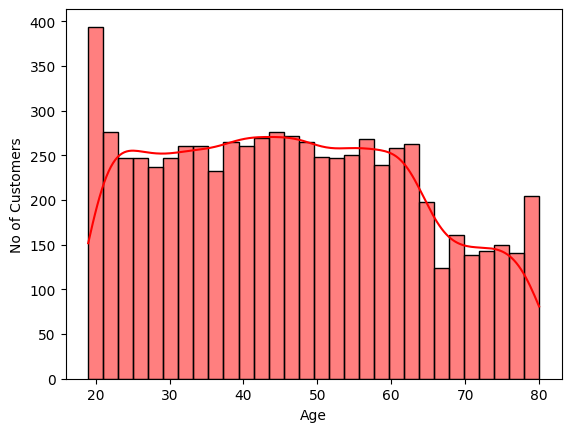

count    7043.000000
mean       46.509726
std        16.750352
min        19.000000
25%        32.000000
50%        46.000000
75%        60.000000
max        80.000000
Name: Age, dtype: float64


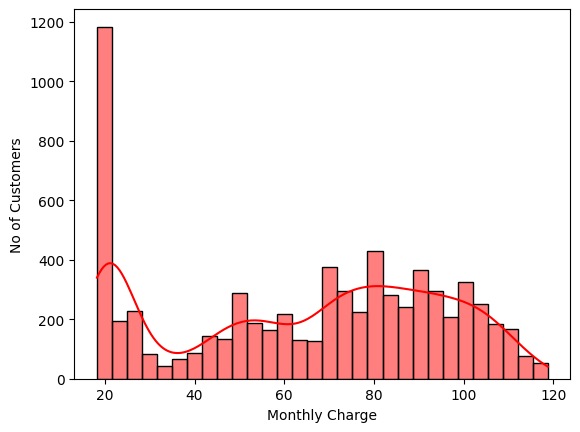

count    7043.000000
mean       64.761692
std        30.090047
min        18.250000
25%        35.500000
50%        70.350000
75%        89.850000
max       118.750000
Name: Monthly Charge, dtype: float64


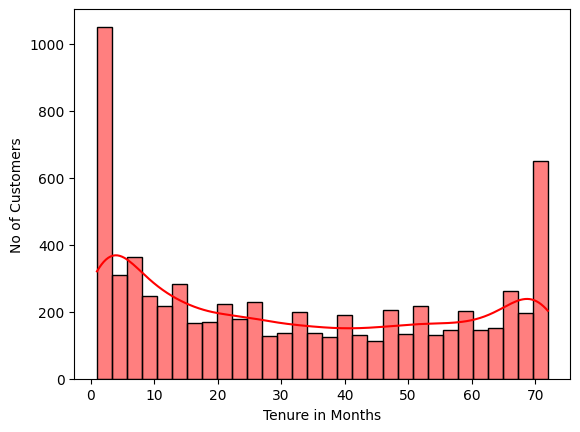

count    7043.000000
mean       32.386767
std        24.542061
min         1.000000
25%         9.000000
50%        29.000000
75%        55.000000
max        72.000000
Name: Tenure in Months, dtype: float64


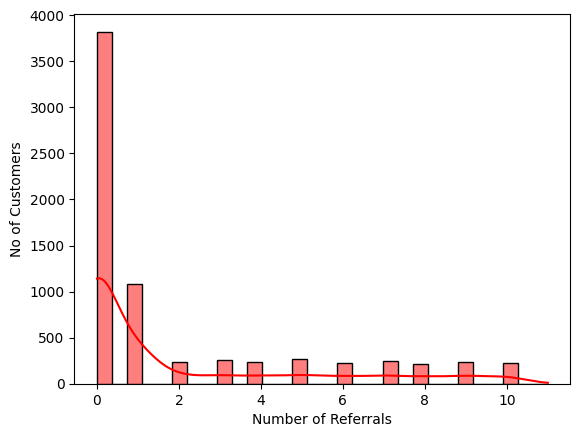

count    7043.000000
mean        1.951867
std         3.001199
min         0.000000
25%         0.000000
50%         0.000000
75%         3.000000
max        11.000000
Name: Number of Referrals, dtype: float64


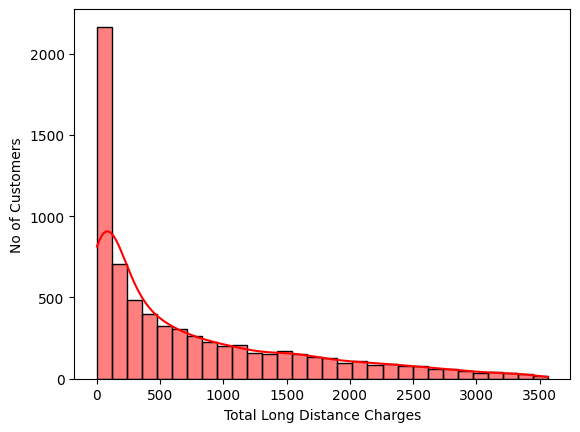

count    7043.000000
mean      749.099262
std       846.660055
min         0.000000
25%        70.545000
50%       401.440000
75%      1191.100000
max      3564.720000
Name: Total Long Distance Charges, dtype: float64


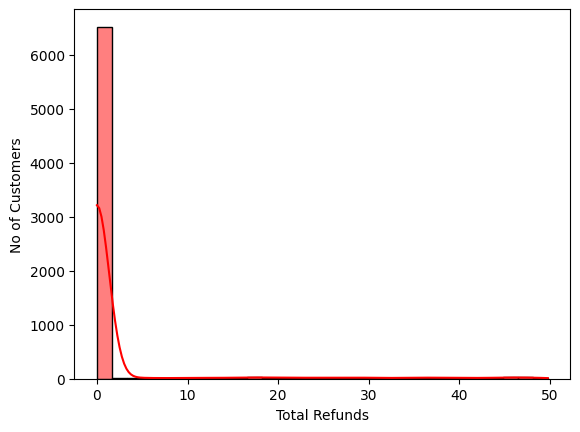

count    7043.000000
mean        1.962182
std         7.902614
min         0.000000
25%         0.000000
50%         0.000000
75%         0.000000
max        49.790000
Name: Total Refunds, dtype: float64


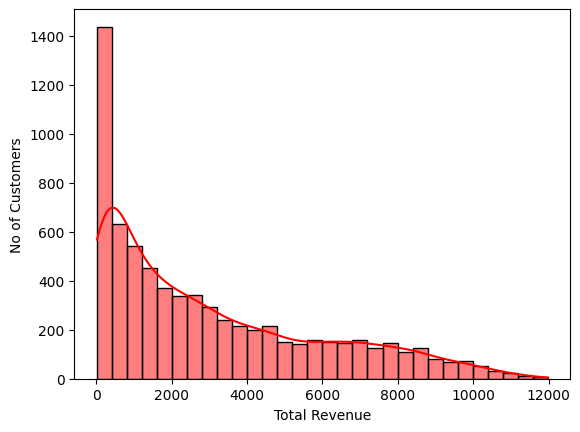

count     7043.000000
mean      3034.379056
std       2865.204542
min         21.360000
25%        605.610000
50%       2108.640000
75%       4801.145000
max      11979.340000
Name: Total Revenue, dtype: float64


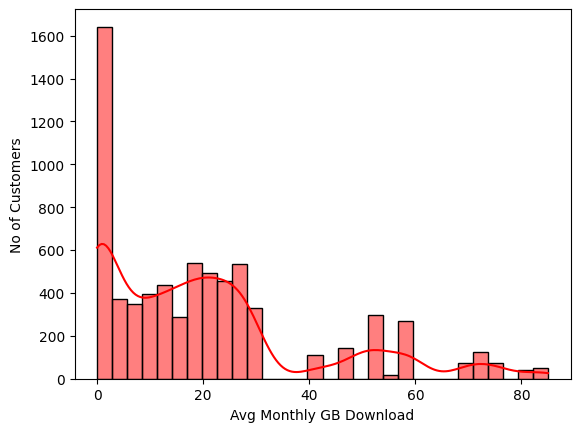

count    7043.000000
mean       20.515405
std        20.418940
min         0.000000
25%         3.000000
50%        17.000000
75%        27.000000
max        85.000000
Name: Avg Monthly GB Download, dtype: float64


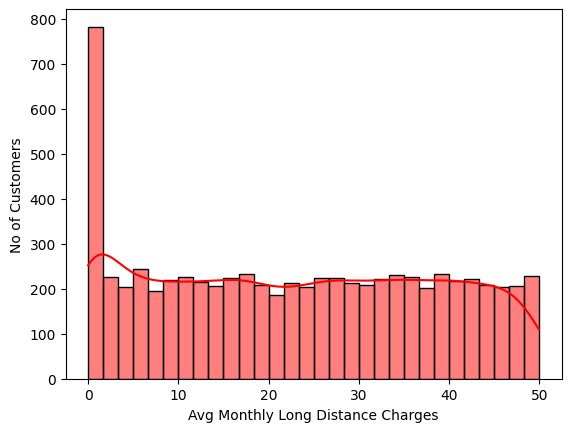

count    7043.000000
mean       22.958954
std        15.448113
min         0.000000
25%         9.210000
50%        22.890000
75%        36.395000
max        49.990000
Name: Avg Monthly Long Distance Charges, dtype: float64


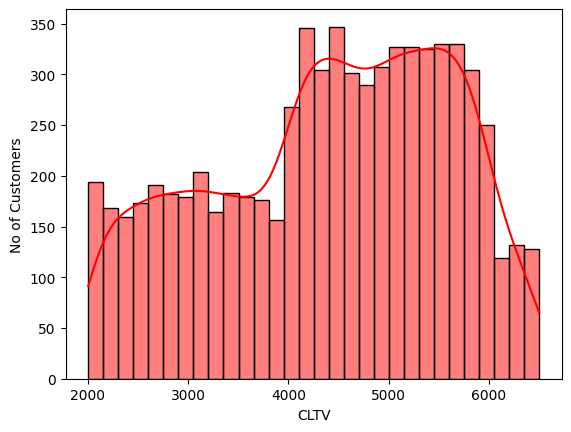

count    7043.000000
mean     4400.295755
std      1183.057152
min      2003.000000
25%      3469.000000
50%      4527.000000
75%      5380.500000
max      6500.000000
Name: CLTV, dtype: float64


In [7]:
Numeric_List=["Age","Monthly Charge","Tenure in Months","Number of Referrals",'Total Long Distance Charges','Total Refunds','Total Revenue','Avg Monthly GB Download',
'Avg Monthly Long Distance Charges',"CLTV",]
for i in Numeric_List:
  sns.histplot(x=i,data=df,bins=30,kde=True,color='red')
  plt.xlabel(i)
  plt.ylabel("No of Customers")
  plt.show()
  print(df[i].describe())

## 6.2.2 Univariate Analysis – Numerical Features

### Age
- Customers fall within a reasonable range (19–80 years).
- Distribution is fairly balanced, with most customers in the middle age group (30–60 years).

No extreme bias in age distribution.

---

### Monthly Charges
- Customers are spread across low to high pricing plans.
- Two clear groups are visible:
  - Lower charges (~20–40)
  - Higher charges (~70–110)

Indicates presence of **basic and premium plans**.

---

### Tenure (Customer Lifetime)
- Customers range from very new (1 month) to long-term (up to 72 months).
- Majority fall in mid-range tenure.

Mix of new and loyal customers in dataset.

---

### Customer Engagement (Referrals)
- Most customers do not refer others (median = 0).
- A small group contributes multiple referrals.

Referral behavior is **skewed and limited to few users**.

---

### Charges & Spending
- Features like:
  - Total Long Distance Charges  
  - Total Revenue  
  show strong positive skewness.

Most customers spend moderate amounts, while a few high-value customers contribute heavily.

---

### Refund
- Majority of customers have zero refunds.

 Refunds are rare and limited to a small subset.

---

### Data Usage
- Average monthly data usage varies widely.
- Most customers use moderate data, while a small group consumes very high data.

Indicates **different usage segments (light vs heavy users)**.

---


Age : 
        count       mean        std   min   25%   50%   75%   max
Churn                                                            
0      5174.0  45.344414  16.276025  19.0  32.0  45.0  58.0  80.0
1      1869.0  49.735688  17.604893  19.0  35.0  50.0  65.0  80.0


Monthly Charge : 
        count       mean        std    min    25%     50%   75%     max
Churn                                                                  
0      5174.0  61.265124  31.092648  18.25  25.10  64.425  88.4  118.75
1      1869.0  74.441332  24.666053  18.85  56.15  79.650  94.2  118.35


Tenure in Months : 
        count       mean        std  min   25%   50%   75%   max
Churn                                                           
0      5174.0  37.591225  24.085029  1.0  15.0  38.0  61.0  72.0
1      1869.0  17.979133  19.531123  1.0   2.0  10.0  29.0  72.0


Number of Referrals : 
        count      mean       std  min  25%  50%  75%   max
Churn                                                 

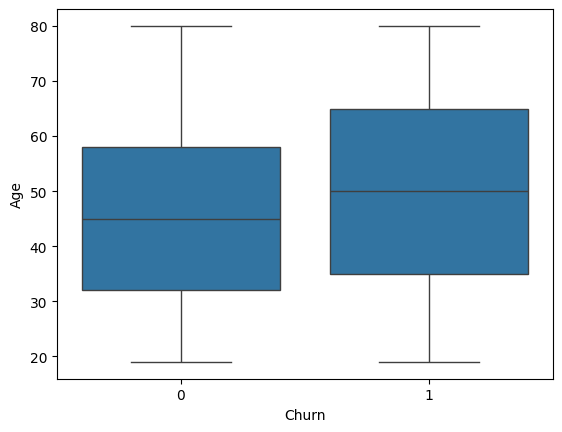

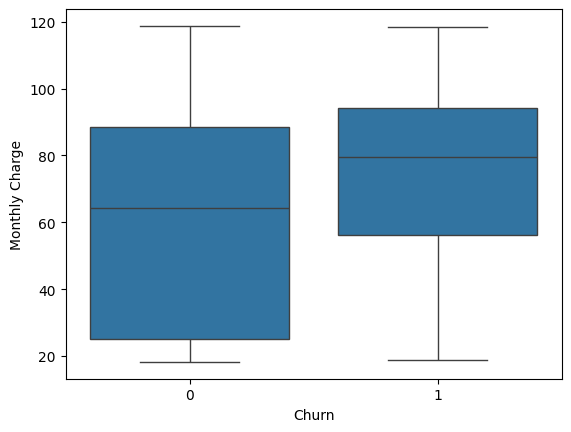

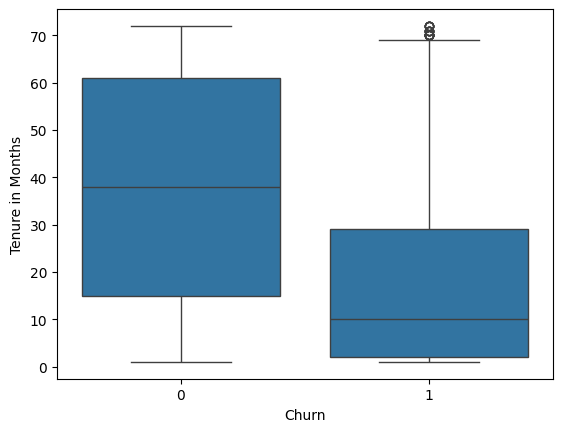

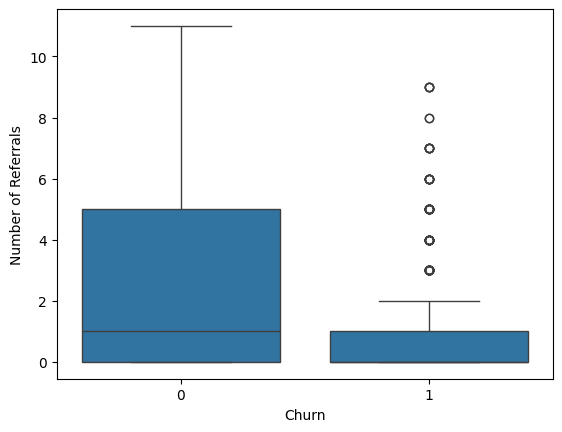

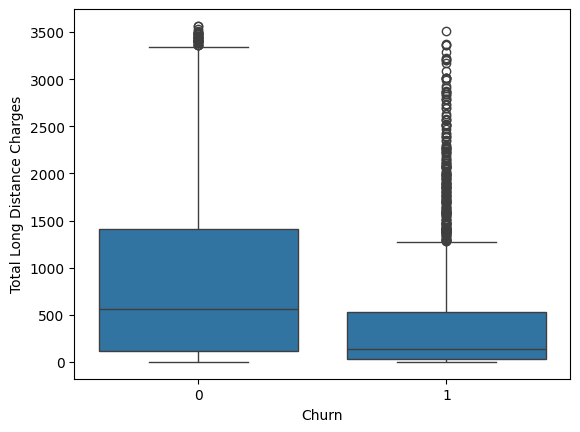

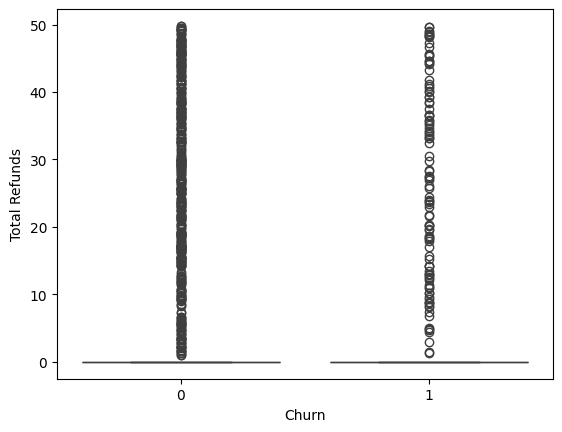

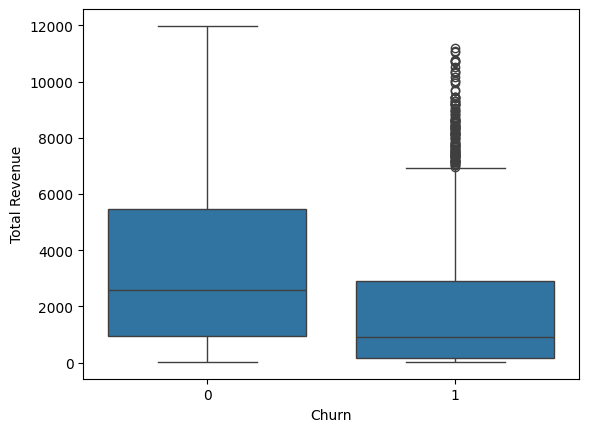

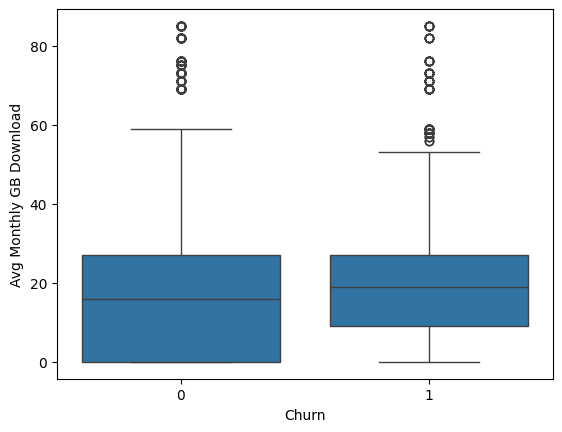

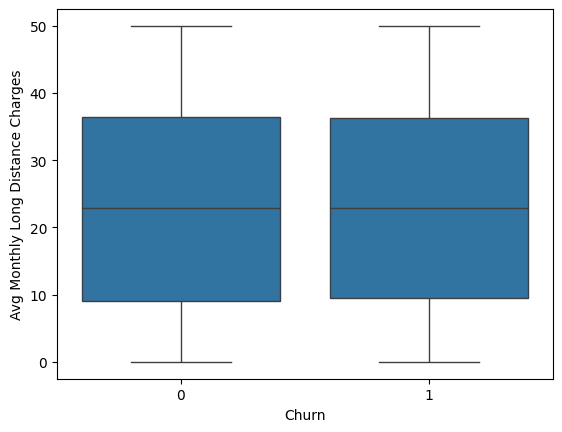

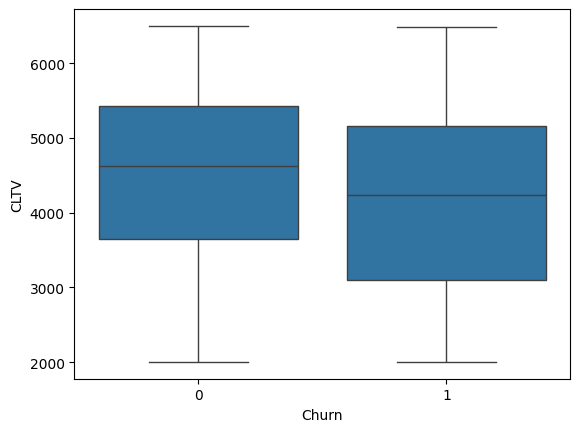

In [8]:
#Bi-variate analysis
Numerical_List=["Age","Monthly Charge","Tenure in Months","Number of Referrals",'Total Long Distance Charges','Total Refunds','Total Revenue','Avg Monthly GB Download',
'Avg Monthly Long Distance Charges',"CLTV",]
for i in Numerical_List:
  print(i,": ")
  print(df.groupby("Churn")[i].describe())
  print()
  print()

for i in Numerical_List:
  sns.boxplot(x="Churn",y=i,data=df)
  plt.show()

# 6.3.1 Bivariate Analysis Insights

Bivariate analysis is performed to understand the relationship between independent features and the target variable (Churn).
By comparing churned and non-churned customers we can identify which factors influence customer churn.

# Numerical Features vs Churn
1.**Age**

*   The average age of customers who stayed is 45.34 years, while customers who churned have an average age of 49.73 years.

*   This indicates that churned customers are slightly older.

*   However, the difference is small, suggesting Age may not be a strong predictor of churn.

2.**Monthly Charges**

*   Customers who stayed pay an average monthly charge of 61.26, while churned customers pay 74.44 on average.

*   This shows that customers with higher monthly charges are more likely to churn.

*   Pricing may be a key factor influencing churn behaviour.

3.**Tenure in Months**

*   Customers who stayed have an average tenure of 37.59 months, while churned customers have only 17.97 months.

*   The median tenure for churned customers is 10 months, compared to 38 months for retained customers.

*   This suggests that new customers are more likely to churn than long-term customers.

4. **Number of Referrals**

*   Customers who stayed have an average of 2.46 referrals, while churned customers have only 0.52 referrals.

*   This indicates that customers who refer others are more engaged and loyal, and therefore less likely to churn.

5. **Total Long Distance Charges**

*   Customers who stayed have significantly higher total long-distance charges (862.95) compared to churned customers (433.91).

*   This suggests that customers who use the service more actively are less likely to churn.

6. **Total Refunds**

*   The average refunds for stayed customers (2.12) and churned customers (1.51) are relatively similar.

*   This indicates that refunds do not strongly impact churn behaviour.

7. **Total Revenue**

*   Customers who stayed generated higher average revenue (3418) compared to churned customers (1971).

*   This shows that long-term customers contribute more revenue, while churned customers usually leave earlier.

8. **Avg Monthly GB Download**

*   Churned customers download slightly more data (22.17 GB) compared to retained customers (19.91 GB).

*   This may indicate that heavy internet users may churn due to service expectations or better offers from competitors.

9. **Avg Monthly Long Distance Charges**

*   The average values for both churned and retained customers are almost the same.

*   This suggests that average monthly long-distance charges have little influence on churn.

10. **Customer Lifetime Value (CLTV)**

*   Customers who stayed have a higher average CLTV (4490) compared to churned customers (4149).

*   This shows that high-value customers tend to stay longer with the company.

Gender : 
Churn           0          1
Gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338




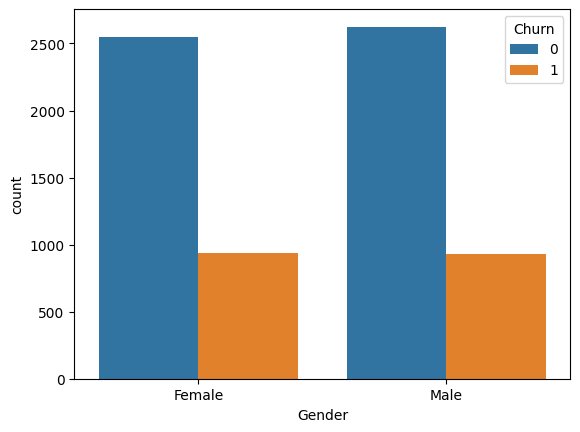


Married : 
Churn            0          1
Married                      
0        67.042021  32.957979
1        80.335097  19.664903




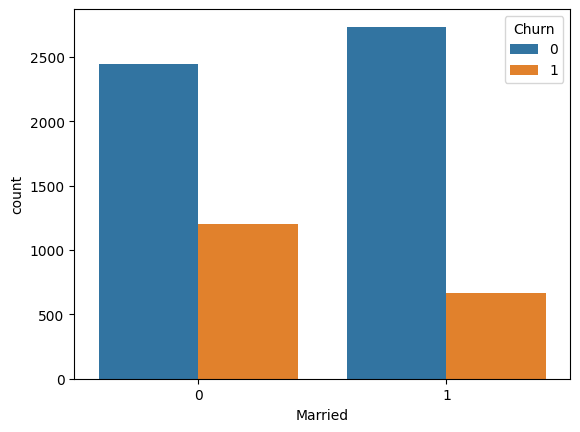


Dependents : 
Churn               0          1
Dependents                      
0           67.448301  32.551699
1           93.484942   6.515058




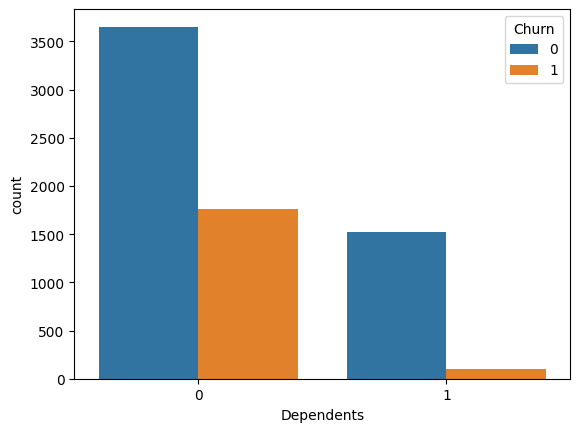


Number of Dependents : 
Churn                          0          1
Number of Dependents                       
0                      67.448301  32.551699
1                      93.128391   6.871609
2                      93.785311   6.214689
3                      94.197292   5.802708
4                      88.888889  11.111111
5                      80.000000  20.000000
6                      66.666667  33.333333
7                      50.000000  50.000000
8                     100.000000   0.000000
9                     100.000000   0.000000




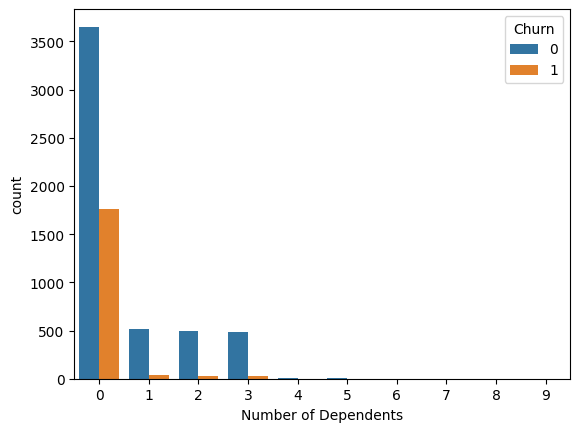


Contract : 
Churn                   0          1
Contract                            
Month-to-Month  54.155125  45.844875
One Year        89.290323  10.709677
Two Year        97.450876   2.549124




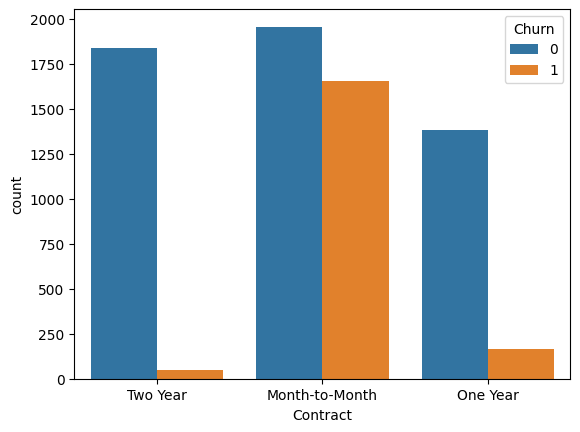


Internet Type : 
Churn                  0          1
Internet Type                      
Cable          74.337349  25.662651
DSL            81.416465  18.583535
Fiber Optic    59.275124  40.724876
Unknown        92.595020   7.404980




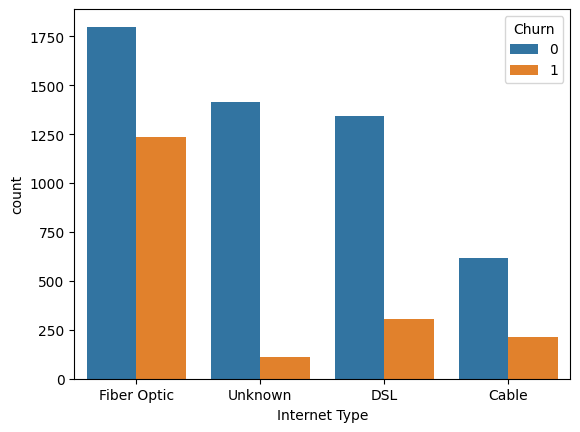


Offer : 
Churn             0          1
Offer                         
No Offer  72.891411  27.108589
Offer A   93.269231   6.730769
Offer B   87.742718  12.257282
Offer C   77.108434  22.891566
Offer D   73.255814  26.744186
Offer E   47.080745  52.919255




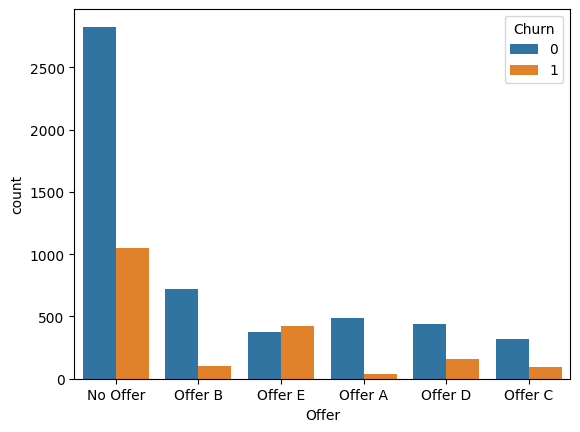


Payment Method : 
Churn                    0          1
Payment Method                       
Bank Withdrawal  66.001535  33.998465
Credit Card      85.522008  14.477992
Mailed Check     63.116883  36.883117




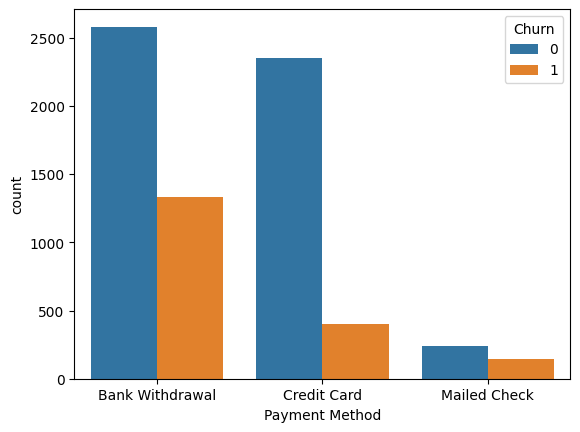


Device Protection Plan : 
Churn                           0          1
Device Protection Plan                      
0                       71.348193  28.651807
1                       77.497936  22.502064




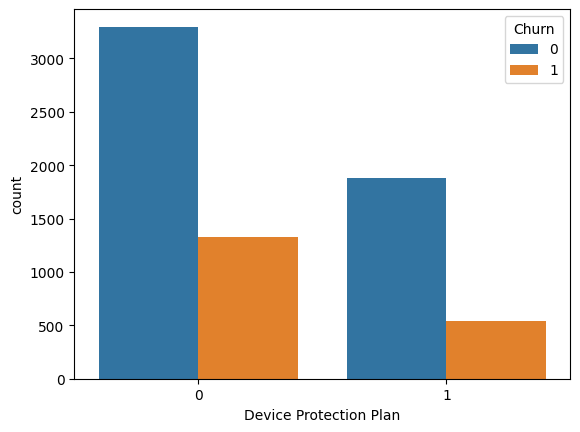


Internet Service : 
Churn                     0          1
Internet Service                      
0                 92.595020   7.404980
1                 68.171107  31.828893




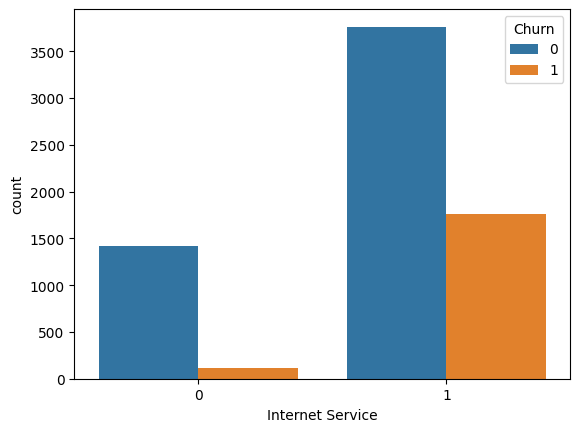


Multiple Lines : 
Churn                   0          1
Multiple Lines                      
0               74.975442  25.024558
1               71.390104  28.609896




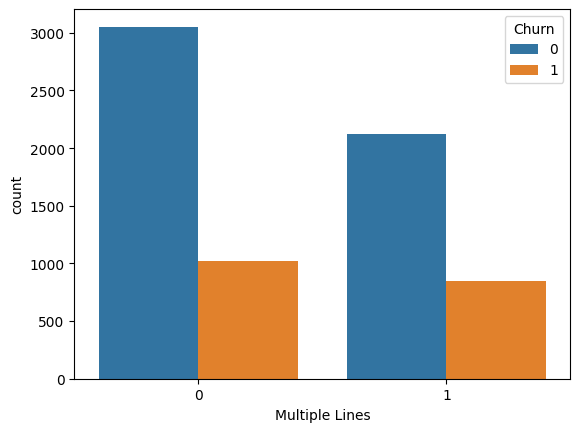


Online Backup : 
Churn                  0          1
Online Backup                      
0              70.827915  29.172085
1              78.468506  21.531494




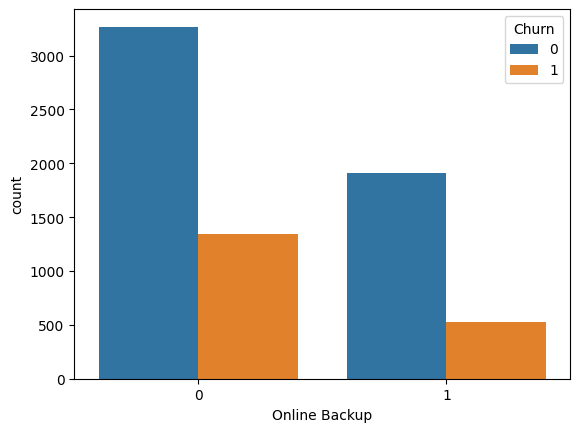


Online Security : 
Churn                    0          1
Online Security                      
0                68.670382  31.329618
1                85.388806  14.611194




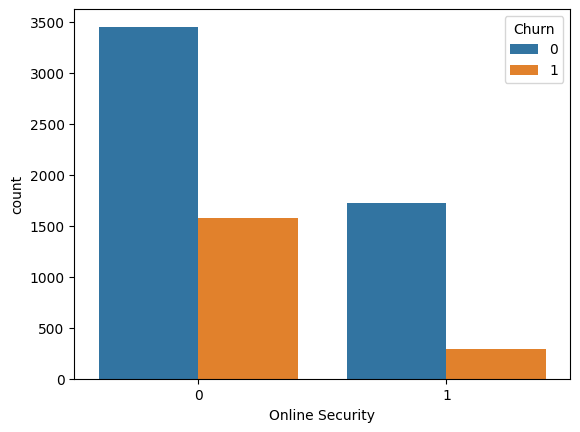


Paperless Billing : 
Churn                      0          1
Paperless Billing                      
0                  83.669916  16.330084
1                  66.434908  33.565092




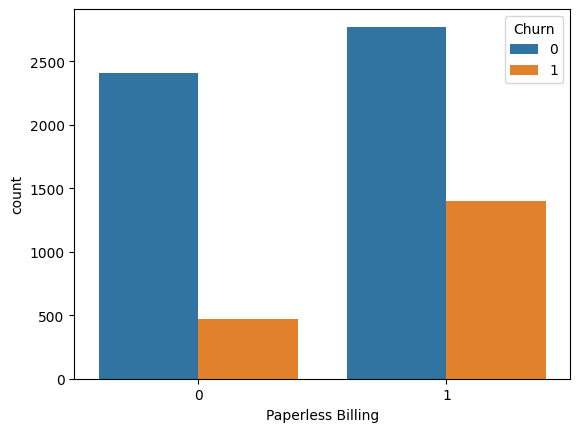


Partner : 
Churn            0          1
Partner                      
0        67.042021  32.957979
1        80.335097  19.664903




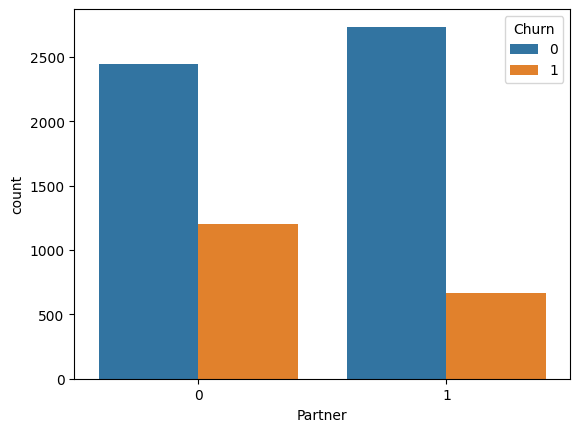


Phone Service : 
Churn                  0          1
Phone Service                      
0              75.073314  24.926686
1              73.290363  26.709637




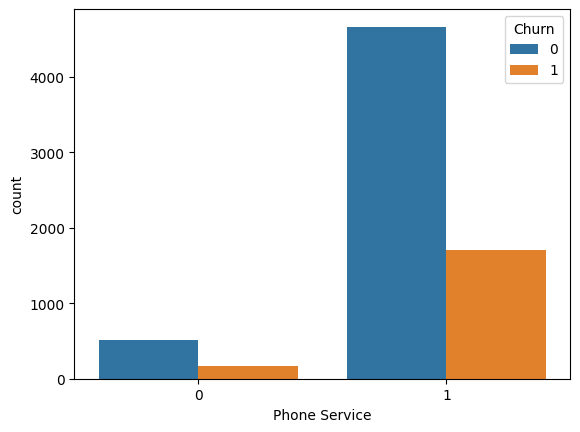


Streaming Movies : 
Churn                     0          1
Streaming Movies                      
0                 75.620506  24.379494
1                 70.058565  29.941435




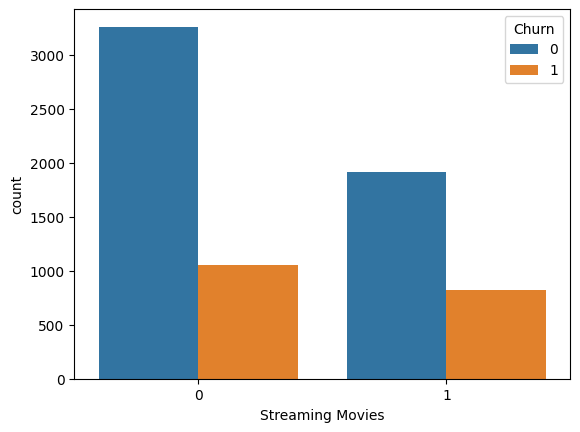


Streaming Music : 
Churn                    0          1
Streaming Music                      
0                74.950604  25.049396
1                70.739550  29.260450




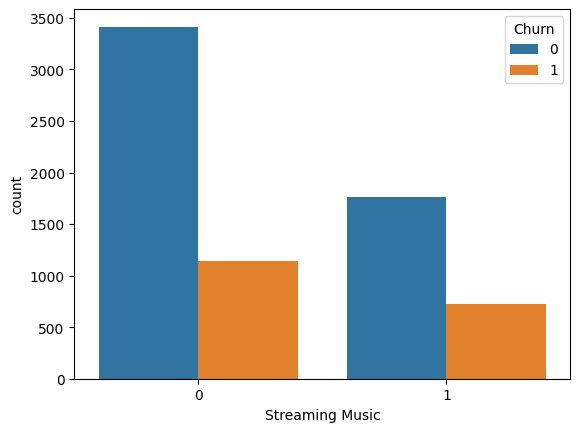


Streaming TV : 
Churn                 0          1
Streaming TV                      
0             75.668819  24.331181
1             69.929812  30.070188




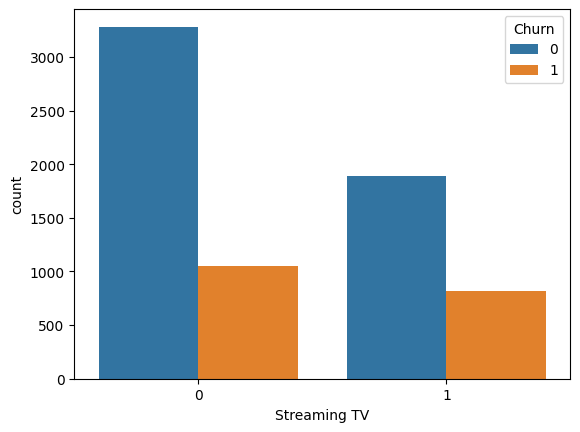


Unlimited Data : 
Churn                   0          1
Unlimited Data                      
0               84.029591  15.970409
1               68.345627  31.654373




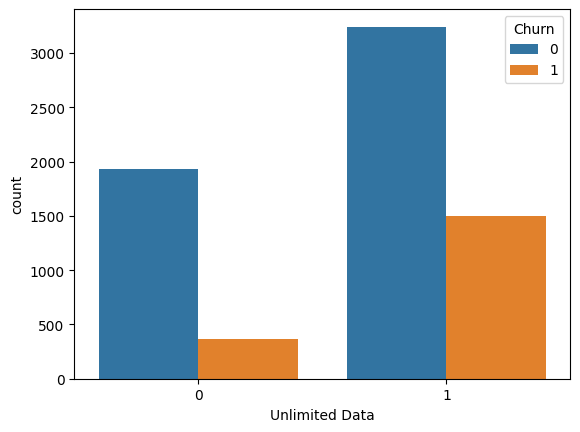

In [9]:
Categorical_List=['Gender','Married','Dependents','Number of Dependents',"Contract","Internet Type","Offer","Payment Method","Device Protection Plan",
                  "Internet Service","Multiple Lines","Online Backup","Online Security","Paperless Billing","Partner","Phone Service","Streaming Movies",
                  "Streaming Music","Streaming TV","Unlimited Data"]
for i in Categorical_List:
  print(i,": ")
  print(pd.crosstab(df[i], df["Churn"], normalize="index") * 100)
  print()
  print()
  sns.countplot(x=i,hue='Churn',data=df)

  plt.show()
  print()

##6.3.2 Insights from Bivariate Analysis (Categorical Features vs Churn)

1.**Gender**

The churn percentage for female customers is 26.92% and for male customers is 26.16%.

The difference between the two is very small.

This indicates that gender does not significantly influence customer churn.

2.**Married**

Customers who are not married have a churn rate of 32.95%, while married customers have a churn rate of 19.66%.

This shows that married customers are more likely to stay with the telecom service.

Married customers may prefer stability in their service providers.

3.**Dependents**

Customers without dependents have a churn rate of 32.55%, while customers with dependents have only 6.51% churn.

This indicates that customers with dependents are far less likely to churn.

Families tend to stay with the same telecom provider for longer periods.

4.**Number of Dependents**

Customers with 0 dependents have the highest churn rate (32.55%).

Customers with 1–3 dependents have very low churn rates (around 5–7%).

This further confirms that family customers are more loyal and less likely to switch providers.

5.**Contract**

Customers with Month-to-Month contracts have the highest churn rate (45.84%).

Customers with One-Year contracts have a churn rate of 10.70%.

Customers with Two-Year contracts have the lowest churn rate (2.54%).

This indicates that long-term contracts significantly reduce customer churn.

6.**Internet Type**

Customers using Fiber Optic internet have the highest churn rate (40.72%).

Customers using DSL have lower churn (18.58%).

Customers with unknown or no internet service have very low churn (7.40%).

This may indicate that fiber optic users have higher expectations or face service issues.

7.**Offer**

Customers with Offer A and Offer B have very low churn rates (6.7% and 12.25%).

Customers with Offer E have the highest churn rate (52.91%).

Customers with no offer have a churn rate of 27.10%.

This suggests that promotional offers can strongly influence customer retention.

8.**Payment Method**

Customers using Credit Card payments have the lowest churn rate (14.47%).

Customers using Bank Withdrawal have a churn rate of 33.99%.

Customers using Mailed Check have the highest churn rate (36.88%).

This indicates that automatic digital payments are associated with better customer retention.

9.**Device Protection Plan**

Customers without device protection have a churn rate of 28.65%.

Customers with device protection have a lower churn rate of 22.50%.

This suggests that customers who purchase additional services are slightly more loyal.

10.**Internet Service**

Customers without internet service have a very low churn rate (7.40%).

Customers with internet service have a higher churn rate (31.82%).

This may indicate that internet-related issues could influence customer churn.

11.**Multiple Lines**

Customers without multiple lines have a churn rate of 25.02%.

Customers with multiple lines have a churn rate of 28.60%.

The difference is small, suggesting multiple lines do not strongly impact churn.

12.**Online Backup**

Customers without online backup have a churn rate of 29.17%.

Customers with online backup have a lower churn rate of 21.53%.

This indicates that customers who use additional services tend to stay longer with the provider.

13.**Online Security**

Customers without online security have a churn rate of 31.33%.

Customers with online security have a much lower churn rate of 14.61%.

This suggests that security services improve customer retention.

14.**Paperless Billing**

Customers without paperless billing have a churn rate of 16.33%.

Customers with paperless billing have a churn rate of 33.56%.

This indicates that customers using paperless billing may change providers more frequently.

15.**Partner**

Customers without a partner have a churn rate of 32.95%.

Customers with a partner have a churn rate of 19.66%.

This again shows that family-based customers are more stable and less likely to churn.

16.**Phone Service**

Customers without phone service have a churn rate of 24.92%.

Customers with phone service have a churn rate of 26.70%.

The difference is small, indicating phone service has limited impact on churn.

17.**Streaming Movies**

Customers without streaming movies have a churn rate of 24.37%.

Customers with streaming movies have a churn rate of 29.94%.

This suggests that streaming services do not strongly prevent churn.

18.**Streaming Music**

Customers without streaming music have a churn rate of 25.04%.

Customers with streaming music have a churn rate of 29.26%.

The difference is moderate and may indicate slightly higher churn among streaming users.

19.**Streaming TV**

Customers without streaming TV have a churn rate of 24.33%.

Customers with streaming TV have a churn rate of 30.07%.

This suggests streaming TV users churn slightly more.

20.**Unlimited Data**

Customers without unlimited data have a churn rate of 15.97%.

Customers with unlimited data have a much higher churn rate of 31.65%.

This indicates that heavy data users may switch providers more frequently, possibly looking for better plans or pricing.

**Key Observations from Categorical Analysis**

The most important factors affecting churn appear to be:

Contract type

Dependents

Online security

Offers

Payment method

Unlimited data

**Key Observations from Numerical Analysis**

The most important factors influencing churn appear to be:

Monthly Charges

Tenure

Number of Referrals

Total Revenue

Total Long Distance Charges

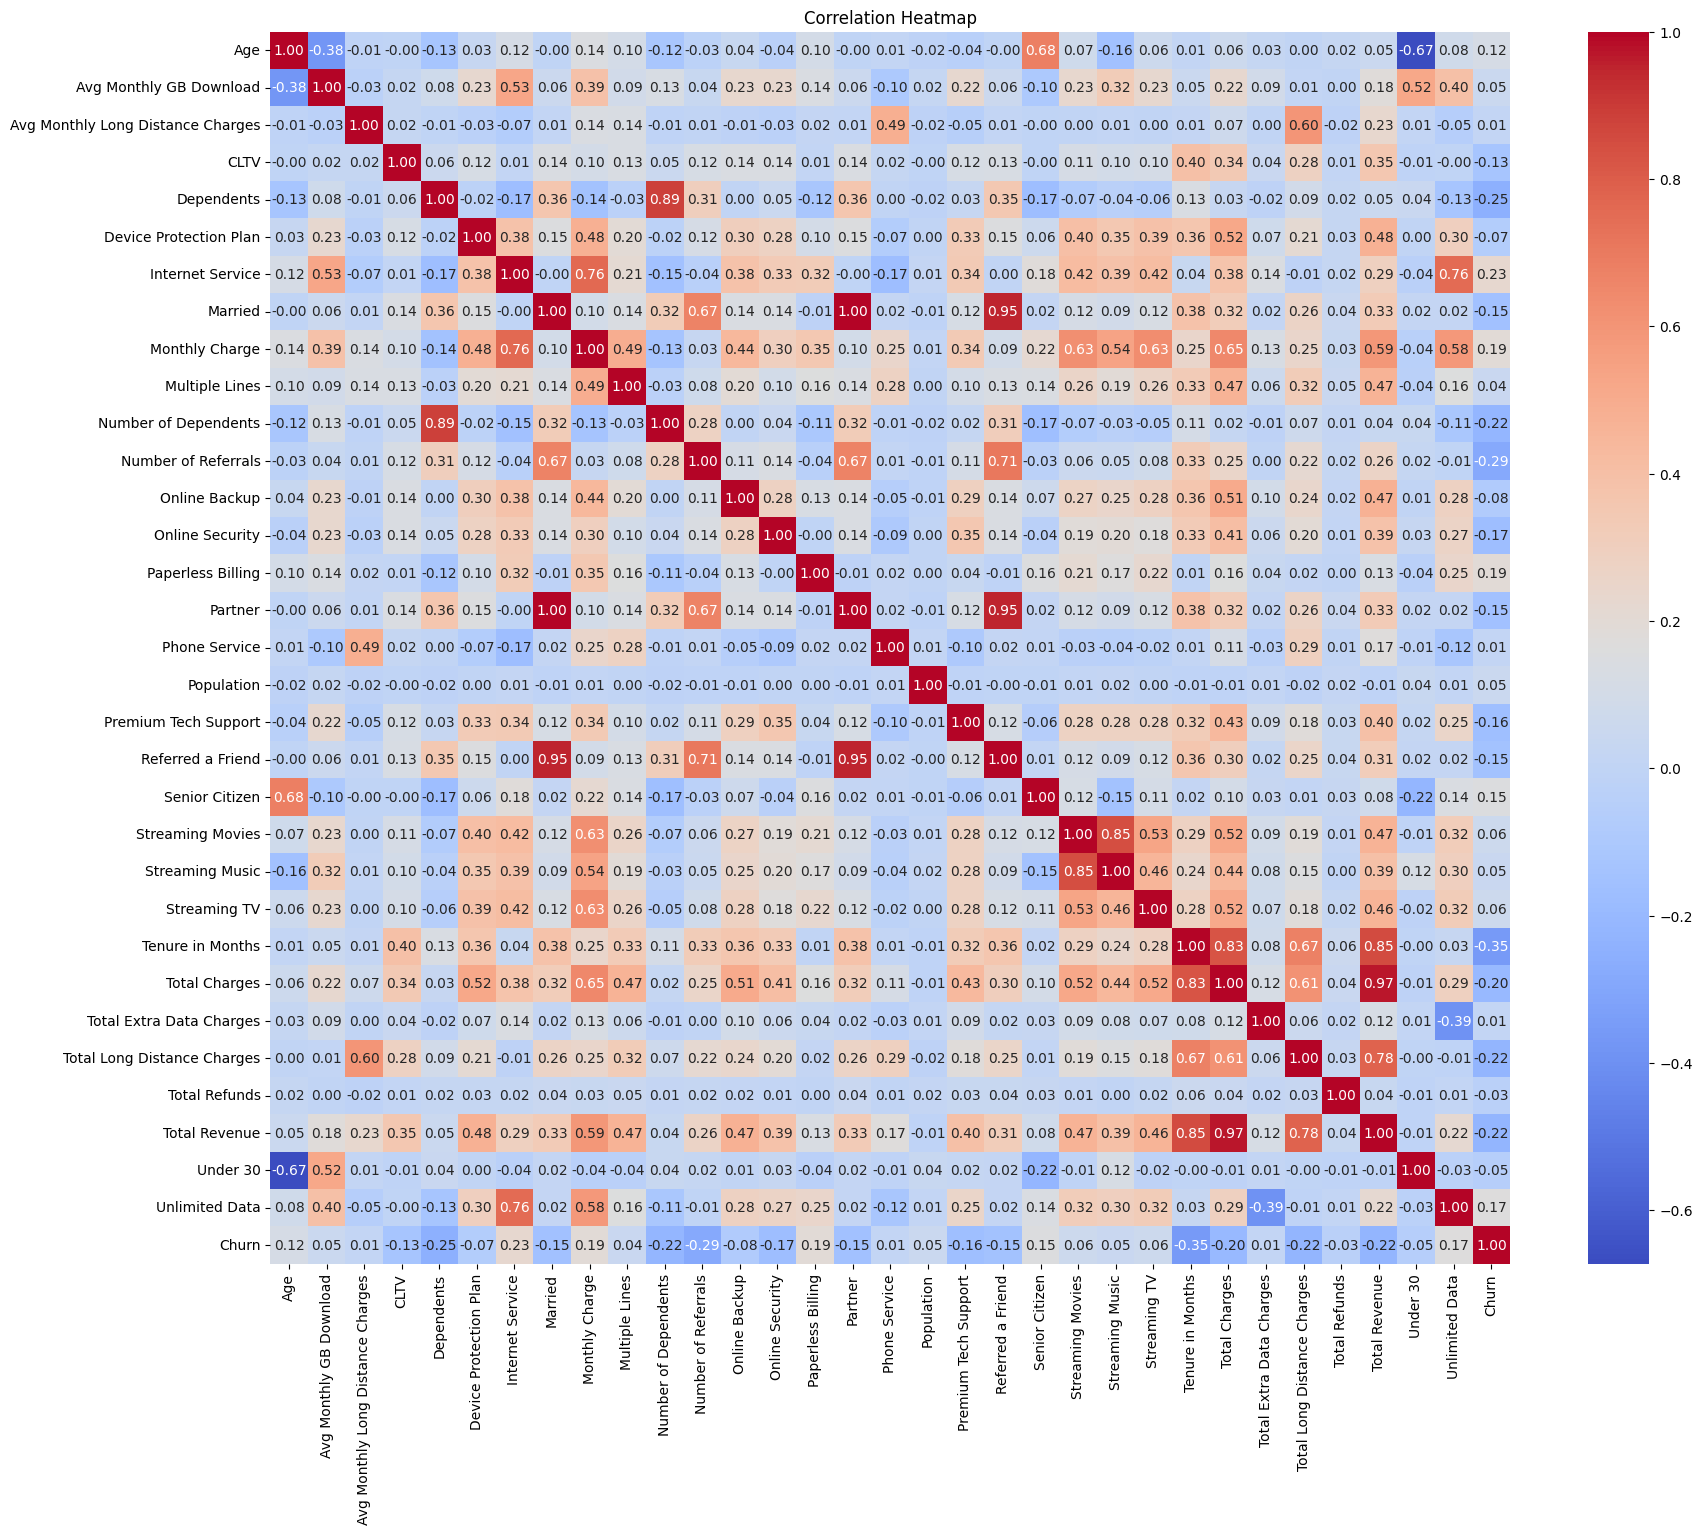

In [10]:
# Correlation Analysis (Numerical Features)


corr_matrix = df.corr(numeric_only=True)

# Display correlation matrix
corr_matrix

# Heatmap visualization
plt.figure(figsize=(20, 16))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

In [11]:
df.drop(["Partner","Referred a Friend","Total Charges","Dependents","Population"], axis=1, inplace=True)
df.shape
df.dropna(subset=["Churn"], inplace=True)
df.isnull().sum()

,0
Age,0
Avg Monthly GB Download,0
Avg Monthly Long Distance Charges,0
CLTV,0
Contract,0
Device Protection Plan,0
Gender,0
Internet Service,0
Internet Type,0
Married,0


In [12]:
#Step-6:Train-Test Split
#Splitting the features and target
X=df.drop("Churn",axis=1)
Y=df["Churn"]

#Splitting to train and test
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,stratify=Y,random_state=42)

# Check shapes
print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", Y_train.shape)
print("y_test:", Y_test.shape)



X_train: (5634, 32)
X_test: (1409, 32)
y_train: (5634,)
y_test: (1409,)


In [14]:
# Step 7: Feature Engineering

from sklearn.preprocessing import StandardScaler, OneHotEncoder

# Split columns
num_cols = X_train.select_dtypes(include=['int64','float64']).columns
cat_cols = X_train.select_dtypes(include=['object']).columns

# SCALING (NUMERICAL)
scaler = StandardScaler()

X_train_num = scaler.fit_transform(X_train[num_cols])
X_test_num = scaler.transform(X_test[num_cols])


# ENCODING (CATEGORICAL)
encoder = OneHotEncoder(handle_unknown='ignore', sparse_output=False)

X_train_cat = encoder.fit_transform(X_train[cat_cols])
X_test_cat = encoder.transform(X_test[cat_cols])

# COMBINE FEATURES


X_train_processed = np.hstack([X_train_num, X_train_cat])
X_test_processed = np.hstack([X_test_num, X_test_cat])

print("Shapes:", X_train_processed.shape, X_test_processed.shape)

Shapes: (5634, 45) (1409, 45)


Perceptron Model Performance:
accuracy: 0.748
precision: 0.535
recall: 0.698
f1: 0.596

PERCEPTRON TEST PERFORMANCE
Confusion Matrix: 
 [[810 225]
 [105 269]]
Accuracy: 0.765791341376863
Precision: 0.5445344129554656
Recall: 0.7192513368983957
F1: 0.619815668202765 





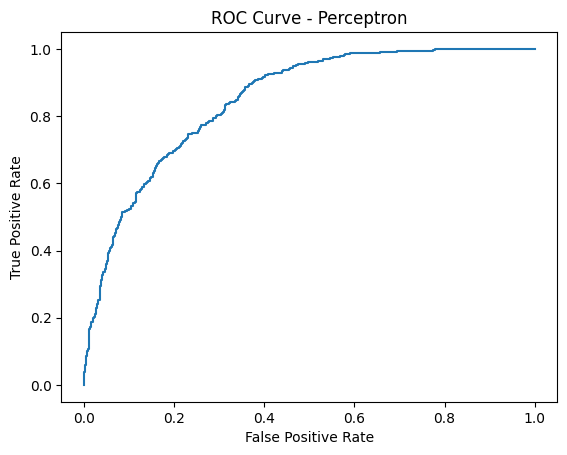

-17.950103452715467
Confusion Matrix: 
 [[665 370]
 [ 42 332]]
Accuracy Score:  0.7075940383250532
Precision_Score:  0.47293447293447294
Recall_Score:  0.8877005347593583
F1 Score:  0.6171003717472119


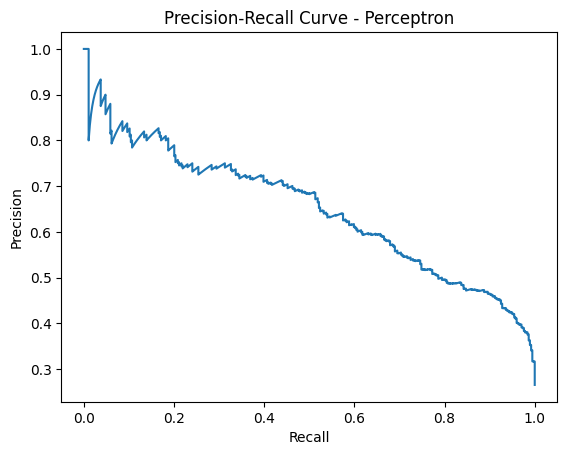

Best Threshold: -9.58864016235405
Confusion Matrix: 
 [[730 305]
 [ 74 300]]
Accuracy Score:  0.7310149041873669
Precision Score:  0.49586776859504134
Recall Score:  0.8021390374331551
F1 Score:  0.6128702757916241


In [15]:
#Step-8.1 Perceptron Model Training

perceptron = Perceptron(class_weight='balanced', random_state=42)
#Evaluting the performance using CV Score.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Perceptron Model Performance:")

for metric in ['accuracy', 'precision', 'recall', 'f1']:
    scores = cross_val_score(perceptron,X_train_processed, Y_train, cv=cv, scoring=metric)
    print(f"{metric}: {scores.mean():.3f}")

#Train the model
perceptron.fit(X_train_processed, Y_train)

#Testing the model
y_pred = perceptron.predict(X_test_processed)
print("\nPERCEPTRON TEST PERFORMANCE")
print("Confusion Matrix: \n",confusion_matrix(Y_test,y_pred))
print("Accuracy:", accuracy_score(Y_test, y_pred))
print("Precision:", precision_score(Y_test, y_pred))
print("Recall:", recall_score(Y_test, y_pred))
print("F1:", f1_score(Y_test, y_pred),"\n\n\n")



# ROC-based threshold (balanced FP and FN)
y_scores = perceptron.decision_function(X_test_processed)
fpr,tpr,thresholds=roc_curve(Y_test,y_scores)
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Perceptron")
plt.show()
#Finding Optimal threshold
optimal_threshold=tpr - fpr
best_idx = optimal_threshold.argmax()
roc_threshold= thresholds[best_idx]
print(roc_threshold)
#Relabelling using the optimal threshold that has been recieved
y_pred_custom = (y_scores >= roc_threshold).astype(int)
#Checking the performance
print("Confusion Matrix: \n",confusion_matrix(Y_test, y_pred_custom))
print("Accuracy Score: ",accuracy_score(Y_test, y_pred_custom))
print("Precision_Score: ",precision_score(Y_test, y_pred_custom))
print("Recall_Score: ",recall_score(Y_test, y_pred_custom))
print("F1 Score: ",f1_score(Y_test, y_pred_custom))


#As the problem is asymetric rather than having balanced approach we try to be biased towards improving recall
precision,recall,thresholds=precision_recall_curve(Y_test,y_scores)
plt.plot(recall,precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Perceptron")
plt.show()

pr_threshold = None
best_precision = 0
for i in range(len(thresholds)):
    if recall[i] >= 0.80:
        if precision[i] > best_precision:
            best_precision = precision[i]
            pr_threshold = thresholds[i]

print("Best Threshold:", pr_threshold)
y_pred_custom = (y_scores >= pr_threshold).astype(int)

#Checking the performance
print("Confusion Matrix: \n",confusion_matrix(Y_test, y_pred_custom))
print("Accuracy Score: ",accuracy_score(Y_test, y_pred_custom))
print("Precision Score: ",precision_score(Y_test, y_pred_custom))
print("Recall Score: ",recall_score(Y_test, y_pred_custom))
print("F1 Score: ",f1_score(Y_test, y_pred_custom))


Logistic Regression Model Performance:
accuracy: 0.790
precision: 0.570
recall: 0.849
f1: 0.682

LOGISTIC TEST PERFORMANCE
Confusion Matrix: 
 [[835 200]
 [ 56 318]]
Accuracy: 0.8183108587650816
Precision: 0.6138996138996139
Recall: 0.8502673796791443
F1: 0.7130044843049327


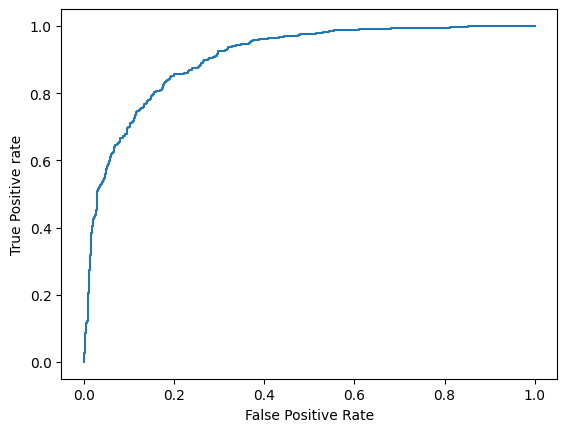

0.5011940531159008
Confusion Matrix: 
 [[835 200]
 [ 56 318]]
Accuracy_Score:  0.8183108587650816
Precision_Score:  0.6138996138996139
Recall Score:  0.8502673796791443
F1 Score:  0.7130044843049327


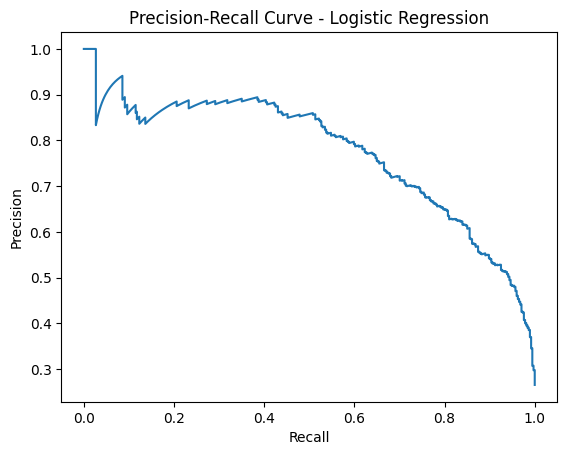

Best Threshold: 0.578917580152265
Confusion Matrix: 
 [[873 162]
 [ 74 300]]
Accuracy Score:  0.8325053229240597
Precision Score:  0.6493506493506493
Recall Score:  0.8021390374331551
F1 Score:  0.7177033492822966


In [16]:
#Step-8.2 Logistic Regression Model Training

logreg = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)

#Evaluting the performance using CV Score.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

print("Logistic Regression Model Performance:")

for metric in ['accuracy', 'precision', 'recall', 'f1']:
    scores = cross_val_score(logreg,X_train_processed, Y_train, cv=cv, scoring=metric)
    print(f"{metric}: {scores.mean():.3f}")

# Train the model
logreg.fit(X_train_processed, Y_train)

# Test the model
y_pred = logreg.predict(X_test_processed)
print("\nLOGISTIC TEST PERFORMANCE")
print("Confusion Matrix: \n",confusion_matrix(Y_test,y_pred))
print("Accuracy:", accuracy_score(Y_test, y_pred))
print("Precision:", precision_score(Y_test, y_pred))
print("Recall:", recall_score(Y_test, y_pred))
print("F1:", f1_score(Y_test, y_pred))



# ROC-based threshold (balanced FP and FN)
y_prob = logreg.predict_proba(X_test_processed)[:,1]
fpr,tpr,thresholds=roc_curve(Y_test,y_prob)

import matplotlib.pyplot as plt
plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive rate")
plt.show()

#Finding the optimal threshold
optimal_threshold=tpr-fpr;
best_idx=optimal_threshold.argmax()
roc_threshold=thresholds[best_idx]
print(roc_threshold)
#Relabelling using the optimal threshold that has been recieved
y_pred_custom = (y_prob >= roc_threshold).astype(int)
#Checking the performance
print("Confusion Matrix: \n",confusion_matrix(Y_test, y_pred_custom))
print("Accuracy_Score: ",accuracy_score(Y_test, y_pred_custom))
print("Precision_Score: ",precision_score(Y_test, y_pred_custom))
print("Recall Score: ",recall_score(Y_test, y_pred_custom))
print("F1 Score: ",f1_score(Y_test, y_pred_custom))


#As the problem is asymetric rather than having balanced approach we try to be biased towards improving recall
precision, recall, thresholds = precision_recall_curve(Y_test, y_prob)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - Logistic Regression")
plt.show()

pr_threshold = None
best_precision = 0
for i in range(len(thresholds)):
    if recall[i] >= 0.80:
        if precision[i] > best_precision:
            best_precision = precision[i]
            pr_threshold = thresholds[i]

print("Best Threshold:", pr_threshold)
y_pred_custom = (y_prob >= pr_threshold).astype(int)

#Checking the performance
print("Confusion Matrix: \n",confusion_matrix(Y_test, y_pred_custom))
print("Accuracy Score: ",accuracy_score(Y_test, y_pred_custom))
print("Precision Score: ",precision_score(Y_test, y_pred_custom))
print("Recall Score: ",recall_score(Y_test, y_pred_custom))
print("F1 Score: ",f1_score(Y_test, y_pred_custom))


SVM TRAINING DATA Performance:
accuracy: 0.808
precision: 0.600
recall: 0.831
f1: 0.697

SVM TEST DATA Performance
Confusion Matrix: 
 [[847 188]
 [ 58 316]]
Accuracy: 0.8254080908445706
Precision: 0.626984126984127
Recall: 0.8449197860962567
F1 Score: 0.7198177676537585


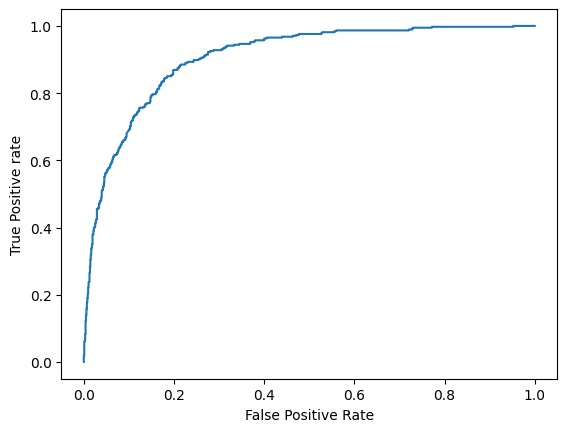

0.6709163243690098
Confusion Matrix: 
 [[991  44]
 [182 192]]
Accuracy Score:  0.8396025550035486
Precision Score:  0.8135593220338984
Recall Score:  0.5133689839572193
F1 Score:  0.6295081967213115


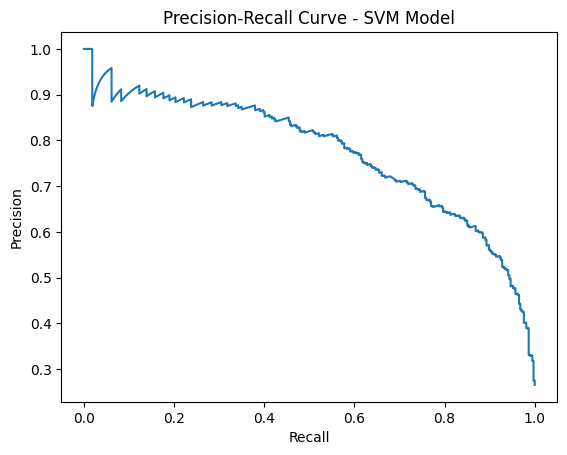

Best Threshold: 0.32994053082846536
Confusion Matrix: 
 [[870 165]
 [ 74 300]]
Accuracy Score:  0.830376153300213
Precision Score:  0.6451612903225806
Recall Score:  0.8021390374331551
F1 Score:  0.7151370679380215


In [17]:
#Step-8.3 SVM Model Training
svm_model = SVC(class_weight='balanced',probability=True,random_state=42,C=1.0,kernel='rbf')

# Evaluating the performance using cv score.
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("SVM TRAINING DATA Performance:")
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    scores = cross_val_score(svm_model, X_train_processed, Y_train, cv=cv, scoring=metric)
    print(f"{metric}: {scores.mean():.3f}")

# Train the model
svm_model.fit(X_train_processed, Y_train)

# Test the model
y_pred_svm = svm_model.predict(X_test_processed)
print("\nSVM TEST DATA Performance")
print("Confusion Matrix: \n",confusion_matrix(Y_test,y_pred_svm))
print("Accuracy:", accuracy_score(Y_test, y_pred_svm))
print("Precision:", precision_score(Y_test, y_pred_svm))
print("Recall:", recall_score(Y_test, y_pred_svm))
print("F1 Score:", f1_score(Y_test, y_pred_svm))


y_prob_svm = svm_model.predict_proba(X_test_processed)[:, 1]
fpr,tpr,thresholds=roc_curve(Y_test,y_prob_svm)
import matplotlib.pyplot as plt
plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive rate")
plt.show()
#Finidng the optimal threshold
optimal_threshold=tpr-fpr;
best_idx=optimal_threshold.argmax()
best_threshold=optimal_threshold[best_idx]
print(best_threshold)
#Relabelling using the optimal threshold that has been recieved.
y_pred_custom = (y_prob_svm >= best_threshold).astype(int)
#Testing the Performance
print("Confusion Matrix: \n",confusion_matrix(Y_test, y_pred_custom))
print("Accuracy Score: ",accuracy_score(Y_test, y_pred_custom))
print("Precision Score: ",precision_score(Y_test, y_pred_custom))
print("Recall Score: ",recall_score(Y_test, y_pred_custom))
print("F1 Score: ",f1_score(Y_test, y_pred_custom))



#As the problem is asymetric rather than having balanced approach we try to be biased towards improving recall
precision, recall, thresholds = precision_recall_curve(Y_test, y_prob_svm)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - SVM Model")
plt.show()

pr_threshold = None
best_precision = 0
for i in range(len(thresholds)):
    if recall[i] >= 0.80:
        if precision[i] > best_precision:
            best_precision = precision[i]
            pr_threshold = thresholds[i]

print("Best Threshold:", pr_threshold)
y_pred_custom = (y_prob_svm >= pr_threshold).astype(int)

#Checking the performance
print("Confusion Matrix: \n",confusion_matrix(Y_test, y_pred_custom))
print("Accuracy Score: ",accuracy_score(Y_test, y_pred_custom))
print("Precision Score: ",precision_score(Y_test, y_pred_custom))
print("Recall Score: ",recall_score(Y_test, y_pred_custom))
print("F1 Score: ",f1_score(Y_test, y_pred_custom))



RANDOM FOREST TRAINING DATA Performance
accuracy: 0.837
precision: 0.752
recall: 0.577
f1: 0.652

RANDOM FOREST TEST DATA Performance
Confusion Matrix: 
 [[965  70]
 [151 223]]
Accuracy: 0.8431511710432931
Precision: 0.7610921501706485
Recall: 0.5962566844919787
F1 Score: 0.6686656671664168


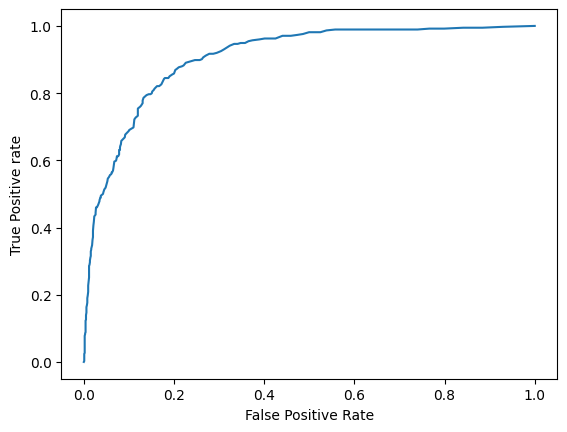

0.24
Confusion Matrix: 
 [[817 218]
 [ 46 328]]
Accuracy Score:  0.8126330731014905
Precision Score:  0.6007326007326007
Recall Score:  0.8770053475935828
F1 Score:  0.7130434782608696


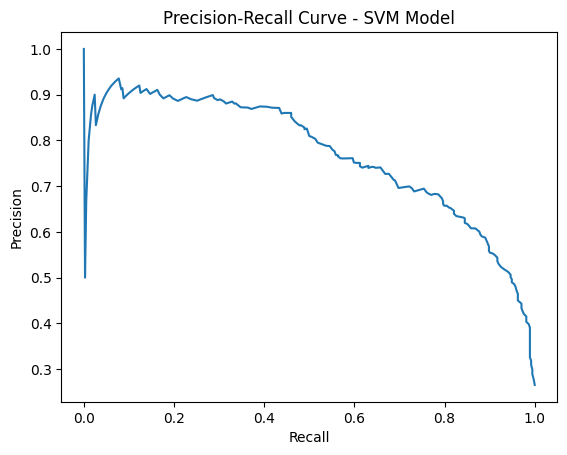

Best Threshold: 0.33
Confusion Matrix: 
 [[878 157]
 [ 73 301]]
Accuracy Score:  0.836763662171753
Precision Score:  0.6572052401746725
Recall Score:  0.8048128342245989
F1 Score:  0.7235576923076923


In [18]:
#Step-8.4 Random Forest Model Training

rf_model = RandomForestClassifier(n_estimators=200,class_weight='balanced',random_state=42,max_depth=None)

#Evaluting the performance using CV score
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
print("RANDOM FOREST TRAINING DATA Performance")
for metric in ['accuracy', 'precision', 'recall', 'f1']:
    scores = cross_val_score(rf_model, X_train_processed, Y_train, cv=cv, scoring=metric)
    print(f"{metric}: {scores.mean():.3f}")

# Train the model
rf_model.fit(X_train_processed, Y_train)

# Test the model
y_pred_rf = rf_model.predict(X_test_processed)
print("\nRANDOM FOREST TEST DATA Performance")
print("Confusion Matrix: \n",confusion_matrix(Y_test,y_pred_rf))
print("Accuracy:", accuracy_score(Y_test, y_pred_rf))
print("Precision:", precision_score(Y_test, y_pred_rf))
print("Recall:", recall_score(Y_test, y_pred_rf))
print("F1 Score:", f1_score(Y_test, y_pred_rf))


y_prob_rf = rf_model.predict_proba(X_test_processed)[:, 1]
fpr,tpr,thresholds=roc_curve(Y_test,y_prob_rf)
import matplotlib.pyplot as plt
plt.plot(fpr,tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive rate")
plt.show()
#Finidng the optimal threshold
optimal_threshold=tpr-fpr;
best_idx=optimal_threshold.argmax()
roc_threshold=thresholds[best_idx]
print(roc_threshold)
#Relabelling using the optimal threshold that has been recieved.
y_pred_custom = (y_prob_rf >= roc_threshold).astype(int)
#Testing the Performance
print("Confusion Matrix: \n",confusion_matrix(Y_test, y_pred_custom))
print("Accuracy Score: ",accuracy_score(Y_test, y_pred_custom))
print("Precision Score: ",precision_score(Y_test, y_pred_custom))
print("Recall Score: ",recall_score(Y_test, y_pred_custom))
print("F1 Score: ",f1_score(Y_test, y_pred_custom))



#As the problem is asymetric rather than having balanced approach we try to be biased towards improving recall
precision, recall, thresholds = precision_recall_curve(Y_test, y_prob_rf)
plt.plot(recall, precision)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve - SVM Model")
plt.show()

pr_threshold = None
best_precision = 0
for i in range(len(thresholds)):
    if recall[i] >= 0.80:
        if precision[i] > best_precision:
            best_precision = precision[i]
            pr_threshold = thresholds[i]

print("Best Threshold:", pr_threshold)
y_pred_custom = (y_prob_rf >= pr_threshold).astype(int)

#Checking the performance
print("Confusion Matrix: \n",confusion_matrix(Y_test, y_pred_custom))
print("Accuracy Score: ",accuracy_score(Y_test, y_pred_custom))
print("Precision Score: ",precision_score(Y_test, y_pred_custom))
print("Recall Score: ",recall_score(Y_test, y_pred_custom))
print("F1 Score: ",f1_score(Y_test, y_pred_custom))



